<a href="https://colab.research.google.com/github/beletedegu2021-lgtm/space-_physics-_project-for-PhD-2026/blob/main/R_H_of_THB_02_09_2007.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


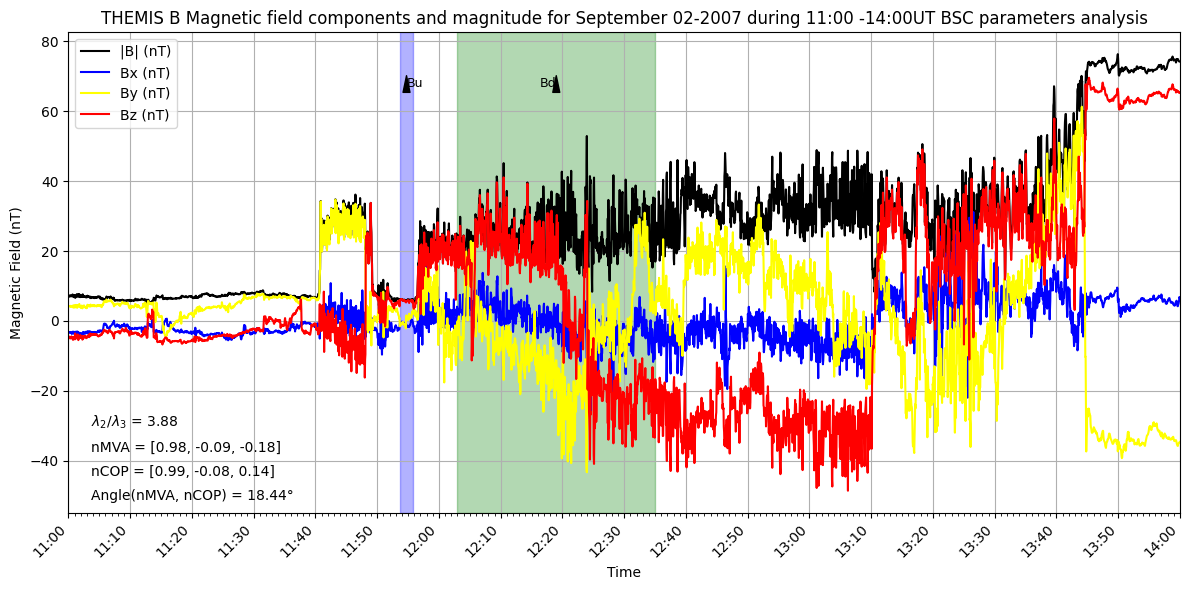

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates

def mva(df, bx_col, by_col, bz_col):
    """
    Performs Minimum Variance Analysis (MVA) on magnetic field data.

    Args:
        df (pd.DataFrame): DataFrame containing magnetic field data.
        bx_col (str): Name of the column for Bx component.
        by_col (str): Name of the column for By component.
        bz_col (str): Name of the column for Bz component.

    Returns:
        tuple: A tuple containing:
            - evals (np.array): Eigenvalues sorted in descending order.
            - evecs (np.array): Eigenvectors corresponding to the sorted eigenvalues.
    """
    B = df[[bx_col, by_col, bz_col]].values
    covariance_matrix = np.cov(B, rowvar=False)
    evals, evecs = np.linalg.eigh(covariance_matrix)

    # Sort eigenvalues and eigenvectors in descending order
    idx = evals.argsort()[::-1]
    evals = evals[idx]
    evecs = evecs[:,idx]

    return evals, evecs

# Re-load df_fgm for THB data
try:
    df_fgm_thb = pd.read_csv('/content/THB_L2_FGM_SEPT11_14.csv') # Update path if necessary
except FileNotFoundError as e:
    print(f"Error loading file for THB: {e}")
    print("Please ensure the CSV file for THB is located in your Google Drive 'My Drive' folder, or update the path.")
    raise # Re-raise the error to stop execution if not handled

# Convert 'UT__yyyy-mm-ddThh:mm:ss.sssZ' to datetime objects
df_fgm_thb['Time'] = pd.to_datetime(df_fgm_thb['UT__yyyy-mm-ddThh:mm:ss.sssZ'])

# Calculate magnetic field magnitude |B|
df_fgm_thb['|B|'] = np.sqrt(
    df_fgm_thb['BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)']**2 +
    df_fgm_thb['BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)']**2 +
    df_fgm_thb['BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)']**2
)

# Define the shock crossing time for THB (PLACEHOLDER - PLEASE UPDATE)
shock_time_thb = pd.to_datetime('2007-09-02T11:56:40Z')

# Define upstream and downstream intervals for THB (PLACEHOLDER - PLEASE UPDATE)
upstream_start_thb = pd.to_datetime('2007-09-02T11:53:40Z') # Extended start time
upstream_end_thb = pd.to_datetime('2007-09-02T11:55:50Z') # Extended end time

downstream_start_thb = pd.to_datetime('2007-09-02T12:03:00Z') # Extended start time
downstream_end_thb = pd.to_datetime('2007-09-02T12:35:00Z') # Extended end time

# --- Create single subplot ---
fig, ax1 = plt.subplots(1, 1, figsize=(12, 6))

# --- Plot 1: Magnetic Field Components and Magnitude ---
ax1.plot(df_fgm_thb['Time'], df_fgm_thb['|B|'], label='|B| (nT)', color='black')
ax1.plot(df_fgm_thb['Time'], df_fgm_thb['BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)'], label='Bx (nT)', color='blue')
ax1.plot(df_fgm_thb['Time'], df_fgm_thb['BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)'], label='By (nT)', color='yellow')
ax1.plot(df_fgm_thb['Time'], df_fgm_thb['BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'], label='Bz (nT)', color='red')

# Add shading for upstream and downstream intervals
ax1.axvspan(upstream_start_thb, upstream_end_thb, color='blue', alpha=0.3) # Increased alpha
ax1.axvspan(downstream_start_thb, downstream_end_thb, color='green', alpha=0.3) # Changed color to green

ax1.set_title('THEMIS B Magnetic field components and magnitude for September 02-2007 during 11:00 -14:00UT BSC parameters analysis')
ax1.set_xlabel('Time')
ax1.set_ylabel('Magnetic Field (nT)')
ax1.grid(True)

# Set x-axis major ticks to 10-minute intervals and minor ticks to 1-minute intervals
ax1.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
ax1.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')) # Format to show hour and minute
plt.xticks(rotation=45, ha='right') # Rotate and align for better readability

# Set x-axis limits to 11:00 to 14:00
ax1.set_xlim(pd.to_datetime('2007-09-02T11:00:00Z'), pd.to_datetime('2007-09-02T14:00:00Z')) # Adjust as needed

# --- MVA and COP Calculations ---
mag_field_cols_thb = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)',
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]
# Perform MVA on the FGM data for THB
evals_thb, evecs_thb = mva(df_fgm_thb, *mag_field_cols_thb)
# Identify the minimum variance direction (shock normal) for THB
MVA_thb = evecs_thb[:, 2] # Eigenvector corresponding to the smallest eigenvalue (lambda_3)

# Calculate average B for upstream and downstream regions for THB
df_upstream_thb = df_fgm_thb[(df_fgm_thb['Time'] >= upstream_start_thb) & (df_fgm_thb['Time'] <= upstream_end_thb)]
df_downstream_thb = df_fgm_thb[(df_fgm_thb['Time'] >= downstream_start_thb) & (df_fgm_thb['Time'] <= downstream_end_thb)]

B_upstream_avg_thb = df_upstream_thb[mag_field_cols_thb].mean().values
B_downstream_avg_thb = df_downstream_thb[mag_field_cols_thb].mean().values

# Calculate nCOP (Coplanarity Normal) for THB
if len(B_upstream_avg_thb) > 0 and len(B_downstream_avg_thb) > 0:
    nCOP_unnormalized_thb = np.cross(B_upstream_avg_thb, B_downstream_avg_thb)
    if np.linalg.norm(nCOP_unnormalized_thb) != 0:
        nCOP_thb = nCOP_unnormalized_thb / np.linalg.norm(nCOP_unnormalized_thb)
    else:
        nCOP_thb = np.array([np.nan, np.nan, np.nan]) # Handle case where cross product is zero
else:
    nCOP_thb = np.array([np.nan, np.nan, np.nan])

# Calculate the angle between MVA and nCOP for THB
dot_product_thb = np.dot(MVA_thb, nCOP_thb)
dot_product_thb = np.clip(dot_product_thb, -1.0, 1.0)
angle_rad_thb = np.arccos(dot_product_thb)
angle_deg_thb = np.degrees(angle_rad_thb)

# Calculate additional ratios for THB
ratio_lambda1_lambda2_thb = evals_thb[0] / evals_thb[1] # lambda_1 / lambda_2
reliability_ratio_thb = evals_thb[1] / evals_thb[2] # lambda_2 / lambda_3

# --- Add original legend for B components ---
ax1.legend(loc='upper left')

# --- Add annotations for shaded regions (adjusted position) ---
ylim_thb = ax1.get_ylim()
y_text_pos = ylim_thb[1] * 0.80 # Position for the text, lower than before
y_arrow_tip_pos = ylim_thb[1] * 0.85 # Position for the arrow tip, slightly higher than text

x_before_bsc_thb = upstream_start_thb + (upstream_end_thb - upstream_start_thb) / 2
ax1.annotate('Bu', xy=(x_before_bsc_thb, y_arrow_tip_pos), xytext=(x_before_bsc_thb, y_text_pos),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             horizontalalignment='left', verticalalignment='bottom', fontsize=9)
x_after_bsc_thb = downstream_start_thb + (downstream_end_thb - downstream_start_thb) / 2
ax1.annotate('Bd', xy=(x_after_bsc_thb, y_arrow_tip_pos), xytext=(x_after_bsc_thb, y_text_pos),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             horizontalalignment='right', verticalalignment='bottom', fontsize=9)

# --- Add MVA, nCOP, and angle as text directly on the plot to the bottom left ---
ax1.text(0.02, 0.17, fr'$ \lambda_2 / \lambda_3 $ = {ratio_lambda1_lambda2_thb:.2f}',
         transform=ax1.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='left')
ax1.text(0.02, 0.12, f'nMVA = [{MVA_thb[0]:.2f}, {MVA_thb[1]:.2f}, {MVA_thb[2]:.2f}]',
         transform=ax1.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='left')
ax1.text(0.02, 0.07, f'nCOP = [{nCOP_thb[0]:.2f}, {nCOP_thb[1]:.2f}, {nCOP_thb[2]:.2f}]',
         transform=ax1.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='left')
ax1.text(0.02, 0.02, f'Angle(nMVA, nCOP) = {angle_deg_thb:.2f}°',
         transform=ax1.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='left')

plt.tight_layout()
plt.savefig('/content/THB_20070902_MVA_COP.png') # Unique filename for THB
plt.show()

In [ ]:
mp = 1.6726e-27 # Mass of a proton in kg

# Placeholder values for number densities (nu, nd) in cm^-3 and velocities (Vu, Vd) in km/s
# YOU SHOULD REPLACE THESE WITH ACTUAL VALUES FROM YOUR DATA OR ASSUMPTIONS
nu = 5.0 # Upstream number density in cm^-3
nd = 15.0 # Downstream number density in cm^-3
Vu = np.array([100.0, -50.0, 20.0]) # Upstream velocity vector in km/s
Vd = np.array([50.0, -20.0, 10.0]) # Downstream velocity vector in km/s

# Use the MVA shock normal calculated previously
normal = MVA_thb

# Calculate mass densities (converted from cm^-3 to m^-3 by multiplying by 1e6)
rho_u = nu * 1e6 * mp # Upstream mass density in kg/m^3
rho_d = nd * 1e6 * mp # Downstream mass density in kg/m^3

# Calculate normal components of velocities
Vnu = np.dot(Vu, normal) # Normal component of upstream velocity in km/s
Vnd = np.dot(Vd, normal) # Normal component of downstream velocity in km/s

print(f"Mass of proton (mp): {mp} kg")
print(f"Upstream number density (nu): {nu} cm^-3")
print(f"Downstream number density (nd): {nd} cm^-3")
print(f"Upstream velocity vector (Vu): {Vu} km/s")
print(f"Downstream velocity vector (Vd): {Vd} km/s")
print(f"Shock normal (normal): {normal}")
print("\nCalculated Plasma Parameters:")
print(f"Upstream mass density (rho_u): {rho_u:.3e} kg/m^3")
print(f"Downstream mass density (rho_d): {rho_d:.3e} kg/m^3")
print(f"Normal component of upstream velocity (Vnu): {Vnu:.2f} km/s")
print(f"Normal component of downstream velocity (Vnd): {Vnd:.2f} km/s")

Mass of proton (mp): 1.6726e-27 kg
Upstream number density (nu): 5.0 cm^-3
Downstream number density (nd): 15.0 cm^-3
Upstream velocity vector (Vu): [100. -50.  20.] km/s
Downstream velocity vector (Vd): [ 50. -20.  10.] km/s
Shock normal (normal): [ 0.98038092 -0.08971612 -0.17551147]

Calculated Plasma Parameters:
Upstream mass density (rho_u): 8.363e-21 kg/m^3
Downstream mass density (rho_d): 2.509e-20 kg/m^3
Normal component of upstream velocity (Vnu): 99.01 km/s
Normal component of downstream velocity (Vnd): 49.06 km/s


In [ ]:
import scipy.constants as const

# Define Boltzmann constant
k_B = const.Boltzmann # J/K

# Placeholder values for upstream and downstream temperatures (in eV)
# YOU SHOULD REPLACE THESE WITH ACTUAL VALUES FROM YOUR DATA
Tu_eV = 10.0  # Upstream temperature in eV
Td_eV = 100.0 # Downstream temperature in eV

# Convert temperatures from eV to Kelvin (1 eV = 11604 K)
Tu = Tu_eV * 11604.0 # Upstream temperature in Kelvin
Td = Td_eV * 11604.0 # Downstream temperature in Kelvin

# Calculate Shock Speed (Vs) using mass conservation equation:
# rho_u * (Vs - Vnu) = rho_d * (Vs - Vnd)
# Vs * (rho_d - rho_u) = rho_d * Vnd - rho_u * Vnu
# Vs = (rho_d * Vnd - rho_u * Vnu) / (rho_d - rho_u)

# Ensure rho_d - rho_u is not zero to avoid division by zero
if (rho_d - rho_u) != 0:
    Vs = (rho_d * Vnd - rho_u * Vnu) / (rho_d - rho_u)
else:
    Vs = np.nan # Or handle the case as appropriate

# Calculate Density Ratio
density_ratio = rho_d / rho_u

# Calculate Pressure using the ideal gas law: P = n * k_B * T
# Convert number densities from cm^-3 to m^-3 by multiplying by 1e6
Pu = (nu * 1e6) * k_B * Tu # Upstream pressure in Pascals
Pd = (nd * 1e6) * k_B * Td # Downstream pressure in Pascals

print(f"\nCalculated Shock Parameters:")
print(f"Upstream Temperature (Tu): {Tu:.2f} K ({Tu_eV:.1f} eV)")
print(f"Downstream Temperature (Td): {Td:.2f} K ({Td_eV:.1f} eV)")
print(f"Shock Speed (Vs): {Vs:.2f} km/s")
print(f"Density Ratio (rho_d / rho_u): {density_ratio:.2f}")
print(f"Upstream Pressure (Pu): {Pu:.3e} Pa")
print(f"Downstream Pressure (Pd): {Pd:.3e} Pa")


Calculated Shock Parameters:
Upstream Temperature (Tu): 116040.00 K (10.0 eV)
Downstream Temperature (Td): 1160400.00 K (100.0 eV)
Shock Speed (Vs): 24.08 km/s
Density Ratio (rho_d / rho_u): 3.00
Upstream Pressure (Pu): 8.011e-12 Pa
Downstream Pressure (Pd): 2.403e-10 Pa


In [ ]:
Vu_s = Vu - Vs * normal
Vd_s = Vd - Vs * normal

print(f"\nTransformed Velocities in Shock Frame:")
print(f"Upstream velocity in shock frame (Vu_s): {Vu_s} km/s")
print(f"Downstream velocity in shock frame (Vd_s): {Vd_s} km/s")


Transformed Velocities in Shock Frame:
Upstream velocity in shock frame (Vu_s): [ 76.39189205 -47.83958691  24.22641201] km/s
Downstream velocity in shock frame (Vd_s): [ 26.39189205 -17.83958691  14.22641201] km/s


In [ ]:
Bu = B_upstream_avg_thb
Bd = B_downstream_avg_thb

# Calculate normal components
Bn_u = np.dot(Bu, normal)
Bn_d = np.dot(Bd, normal)

# Calculate tangential components
Bt_u = Bu - Bn_u * normal
Bt_d = Bd - Bn_d * normal

print(f"\nMagnetic Field Components:")
print(f"Upstream Normal Magnetic Field (Bn_u): {Bn_u:.2f} nT")
print(f"Downstream Normal Magnetic Field (Bn_d): {Bn_d:.2f} nT")
print(f"Upstream Tangential Magnetic Field (Bt_u): {Bt_u} nT")
print(f"Downstream Tangential Magnetic Field (Bt_d): {Bt_d} nT")


Magnetic Field Components:
Upstream Normal Magnetic Field (Bn_u): -1.85 nT
Downstream Normal Magnetic Field (Bn_d): -1.12 nT
Upstream Tangential Magnetic Field (Bt_u): [0.98967537 0.14249238 5.45534145] nT
Downstream Tangential Magnetic Field (Bt_d): [ 0.16593527 -4.94671342  3.45549895] nT


In [ ]:
# Calculate normal components of velocity in the shock frame
Vn_u = np.dot(Vu_s, normal)
Vn_d = np.dot(Vd_s, normal)

# Calculate tangential components of velocity in the shock frame
Vt_u = Vu_s - Vn_u * normal
Vt_d = Vd_s - Vn_d * normal

print(f"\nVelocity Components in Shock Frame:")
print(f"Upstream Normal Velocity (Vn_u): {Vn_u:.2f} km/s")
print(f"Downstream Normal Velocity (Vn_d): {Vn_d:.2f} km/s")
print(f"Upstream Tangential Velocity (Vt_u): {Vt_u} km/s")
print(f"Downstream Tangential Velocity (Vt_d): {Vt_d} km/s")


Velocity Components in Shock Frame:
Upstream Normal Velocity (Vn_u): 74.93 km/s
Downstream Normal Velocity (Vn_d): 24.98 km/s
Upstream Tangential Velocity (Vt_u): [  2.92888915 -41.11687818  37.37803428] km/s
Downstream Tangential Velocity (Vt_d): [  1.90422442 -15.598684    18.6102861 ] km/s


In [ ]:
# Calculate mass flux in the upstream and downstream regions
# Note: Vn_u and Vn_d are in km/s, so we convert them to m/s by multiplying by 1000
mass_u = rho_u * (Vn_u * 1000) # Upstream mass flux in kg/(m^2 * s)
mass_d = rho_d * (Vn_d * 1000) # Downstream mass flux in kg/(m^2 * s)

print("\nTesting RH Equation 1 (Mass Conservation):")
print(f"Upstream Mass Flux (mass_u): {mass_u:.3e} kg/(m^2 * s)")
print(f"Downstream Mass Flux (mass_d): {mass_d:.3e} kg/(m^2 * s)")
print(f"Difference (mass_u - mass_d): {mass_u - mass_d:.3e} kg/(m^2 * s)")


Testing RH Equation 1 (Mass Conservation):
Upstream Mass Flux (mass_u): 6.267e-16 kg/(m^2 * s)
Downstream Mass Flux (mass_d): 6.267e-16 kg/(m^2 * s)
Difference (mass_u - mass_d): 1.972e-31 kg/(m^2 * s)


In [ ]:
print("\nTesting RH Equation 2 (Normal Magnetic Field Conservation):")
print(f"Upstream Normal Magnetic Field (Bn_u): {Bn_u:.2f} nT")
print(f"Downstream Normal Magnetic Field (Bn_d): {Bn_d:.2f} nT")
print(f"Difference (Bn_u - Bn_d): {Bn_u - Bn_d:.2e} nT")


Testing RH Equation 2 (Normal Magnetic Field Conservation):
Upstream Normal Magnetic Field (Bn_u): -1.85 nT
Downstream Normal Magnetic Field (Bn_d): -1.12 nT
Difference (Bn_u - Bn_d): -7.24e-01 nT


In [ ]:
# Calculate upstream electric field Eu
Eu = Vn_u * Bt_u - Bn_u * Vt_u

# Calculate downstream electric field Ed
Ed = Vn_d * Bt_d - Bn_d * Vt_d

print("\nTesting RH Equation 3 (Electric Field Conservation):")
print(f"Upstream Electric Field (Eu): {Eu} (km/s * nT)")
print(f"Downstream Electric Field (Ed): {Ed} (km/s * nT)")
print(f"Difference (Eu - Ed): {Eu - Ed} (km/s * nT)")


Testing RH Equation 3 (Electric Field Conservation):
Upstream Electric Field (Eu): [ 79.57409927 -65.33532234 477.88649204] (km/s * nT)
Downstream Electric Field (Ed): [   6.28604986 -141.09882731  107.23836102] (km/s * nT)
Difference (Eu - Ed): [ 73.28804941  75.76350497 370.64813102] (km/s * nT)


In [ ]:
mu0 = 4 * np.pi * 1e-7 # Permeability of free space in H/m (or N/A^2)

# Calculate upstream momentum (Mom_u) in Pa
# Note: Vn_u is in km/s, so we convert it to m/s by multiplying by 1000
# Bt_u is in nT, so we convert it to T by multiplying by 1e-9
Mom_u = rho_u * (Vn_u * 1000)**2 + Pu + np.dot(Bt_u * 1e-9, Bt_u * 1e-9) / (2 * mu0)

# Calculate downstream momentum (Mom_d) in Pa
# Note: Vn_d is in km/s, so we convert it to m/s by multiplying by 1000
# Bt_d is in nT, so we convert it to T by multiplying by 1e-9
Mom_d = rho_d * (Vn_d * 1000)**2 + Pd + np.dot(Bt_d * 1e-9, Bt_d * 1e-9) / (2 * mu0)

print("\nTesting RH Equation 4 (Momentum Conservation):")
print(f"Upstream Momentum (Mom_u): {Mom_u:.3e} Pa")
print(f"Downstream Momentum (Mom_d): {Mom_d:.3e} Pa")
print(f"Difference (Mom_u - Mom_d): {Mom_u - Mom_d:.3e} Pa")


Testing RH Equation 4 (Momentum Conservation):
Upstream Momentum (Mom_u): 6.721e-11 Pa
Downstream Momentum (Mom_d): 2.705e-10 Pa
Difference (Mom_u - Mom_d): -2.033e-10 Pa


In [ ]:
# Calculate upstream tangential momentum (Tang_u)
# rho_u in kg/m^3, Vn_u in km/s (convert to m/s), Vt_u in km/s (convert to m/s vector)
# Bn_u in nT (convert to T), Bt_u in nT (convert to T vector)
Tang_u = rho_u * (Vn_u * 1000) * (Vt_u * 1000) - ((Bn_u * 1e-9) * (Bt_u * 1e-9)) / mu0

# Calculate downstream tangential momentum (Tang_d)
# rho_d in kg/m^3, Vn_d in km/s (convert to m/s), Vt_d in km/s (convert to m/s vector)
# Bn_d in nT (convert to T), Bt_d in nT (convert to T vector)
Tang_d = rho_d * (Vn_d * 1000) * (Vt_d * 1000) - ((Bn_d * 1e-9) * (Bt_d * 1e-9)) / mu0

print("\nTesting RH Equation 5 (Tangential Momentum Conservation):")
print(f"Upstream Tangential Momentum (Tang_u): {Tang_u} Pa")
print(f"Downstream Tangential Momentum (Tang_d): {Tang_d} Pa")
print(f"Difference (Tang_u - Tang_d): {Tang_u - Tang_d} Pa")


Testing RH Equation 5 (Tangential Momentum Conservation):
Upstream Tangential Momentum (Tang_u): [ 3.29139304e-12 -2.55569099e-11  3.14491451e-11] Pa
Downstream Tangential Momentum (Tang_d): [ 1.34180372e-12 -1.42018582e-11  1.47546730e-11] Pa
Difference (Tang_u - Tang_d): [ 1.94958932e-12 -1.13550517e-11  1.66944721e-11] Pa


In [ ]:
gamma = 5/3 # Adiabatic index for an ideal gas

# Calculate upstream energy flux (Eu) in W/m^2
# Vn_u and Vu_s are in km/s, convert to m/s by multiplying by 1000
Eu_rh6 = (0.5 * rho_u * np.linalg.norm(Vu_s * 1000)**2 + \
          gamma / (gamma - 1) * Pu) * (Vn_u * 1000)

# Calculate downstream energy flux (Ed) in W/m^2
# Vn_d and Vd_s are in km/s, convert to m/s by multiplying by 1000
Ed_rh6 = (0.5 * rho_d * np.linalg.norm(Vd_s * 1000)**2 + \
          gamma / (gamma - 1) * Pd) * (Vn_d * 1000)

print("\nTesting RH Equation 6 (Energy Flux Conservation):")
print(f"Upstream Energy Flux (Eu): {Eu_rh6:.3e} W/m^2")
print(f"Downstream Energy Flux (Ed): {Ed_rh6:.3e} W/m^2")
print(f"Difference (Eu - Ed): {Eu_rh6 - Ed_rh6:.3e} W/m^2")


Testing RH Equation 6 (Energy Flux Conservation):
Upstream Energy Flux (Eu): 4.230e-06 W/m^2
Downstream Energy Flux (Ed): 1.539e-05 W/m^2
Difference (Eu - Ed): -1.116e-05 W/m^2


In [ ]:
def error(a, b):
    return abs(a - b) / max(abs(a), abs(b)) * 100

print(f"Relative Error in Energy Flux Conservation: {error(Eu_rh6, Ed_rh6):.2f}%")

Relative Error in Energy Flux Conservation: 72.51%


In [ ]:
def error(a, b):
    if max(abs(a), abs(b)) == 0:
        return 0.0 # Handle cases where both a and b are zero
    return abs(a - b) / max(abs(a), abs(b)) * 100

# Calculate relative errors for all RH equations

# RH Eq 1 (Mass Conservation)
error_rh1 = error(mass_u, mass_d)

# RH Eq 2 (Normal Magnetic Field Conservation)
error_rh2 = error(Bn_u, Bn_d)

# RH Eq 3 (Electric Field Conservation - using magnitudes)
Eu_mag = np.linalg.norm(Eu)
Ed_mag = np.linalg.norm(Ed)
error_rh3 = error(Eu_mag, Ed_mag)

# RH Eq 4 (Momentum Conservation)
error_rh4 = error(Mom_u, Mom_d)

# RH Eq 5 (Tangential Momentum Conservation - using magnitudes)
Tang_u_mag = np.linalg.norm(Tang_u)
Tang_d_mag = np.linalg.norm(Tang_d)
error_rh5 = error(Tang_u_mag, Tang_d_mag)

# RH Eq 6 (Energy Flux Conservation) - already calculated as error(Eu_rh6, Ed_rh6)
error_rh6 = error(Eu_rh6, Ed_rh6)

# Prepare data for the table
rh_summary_data = {
    'RH Equation': [
        '1 (Mass Conservation)',
        '2 (Normal B Conservation)',
        '3 (Electric Field Conservation)',
        '4 (Momentum Conservation)',
        '5 (Tangential Momentum Conservation)',
        '6 (Energy Flux Conservation)'
    ],
    'Upstream Value': [
        f'{mass_u:.3e} kg/(m^2 * s)',
        f'{Bn_u:.2f} nT',
        f'{Eu_mag:.2f} (km/s * nT)',
        f'{Mom_u:.3e} Pa',
        f'{Tang_u_mag:.3e} Pa',
        f'{Eu_rh6:.3e} W/m^2'
    ],
    'Downstream Value': [
        f'{mass_d:.3e} kg/(m^2 * s)',
        f'{Bn_d:.2f} nT',
        f'{Ed_mag:.2f} (km/s * nT)',
        f'{Mom_d:.3e} Pa',
        f'{Tang_d_mag:.3e} Pa',
        f'{Ed_rh6:.3e} W/m^2'
    ],
    'Difference': [
        f'{(mass_u - mass_d):.3e}',
        f'{(Bn_u - Bn_d):.2e}',
        f'{np.linalg.norm(Eu - Ed):.2f}', # Magnitude of vector difference
        f'{(Mom_u - Mom_d):.3e}',
        f'{np.linalg.norm(Tang_u - Tang_d):.3e}', # Magnitude of vector difference
        f'{(Eu_rh6 - Ed_rh6):.3e}'
    ],
    'Units': [
        'kg/(m^2 * s)',
        'nT',
        '(km/s * nT)',
        'Pa',
        'Pa',
        'W/m^2'
    ],
    'Relative Error (%)': [
        f'{error_rh1:.2f}%',
        f'{error_rh2:.2f}%',
        f'{error_rh3:.2f}%',
        f'{error_rh4:.2f}%',
        f'{error_rh5:.2f}%',
        f'{error_rh6:.2f}%'
    ]
}

rh_summary_df = pd.DataFrame(rh_summary_data)
display(rh_summary_df)

print("\nNote: A relative error of 0.00% often indicates values are identical or extremely close, given floating point precision. Higher errors suggest non-conservation based on the current placeholder values.")

,RH Equation,Upstream Value,Downstream Value,Difference,Units,Relative Error (%)
0,1 (Mass Conservation),6.267e-16 kg/(m^2 * s),6.267e-16 kg/(m^2 * s),1.972e-31,kg/(m^2 * s),0.00%
1,2 (Normal B Conservation),-1.85 nT,-1.12 nT,-7.24e-01,nT,39.17%
2,3 (Electric Field Conservation),488.85 (km/s * nT),177.34 (km/s * nT),385.35,(km/s * nT),63.72%
3,4 (Momentum Conservation),6.721e-11 Pa,2.705e-10 Pa,-2.033e-10,Pa,75.15%
4,5 (Tangential Momentum Conservation),4.066e-11 Pa,2.052e-11 Pa,2.028e-11,Pa,49.52%
5,6 (Energy Flux Conservation),4.230e-06 W/m^2,1.539e-05 W/m^2,-1.116e-05,W/m^2,72.51%



Note: A relative error of 0.00% often indicates values are identical or extremely close, given floating point precision. Higher errors suggest non-conservation based on the current placeholder values.


## THEMIS E Rankine-Hugoniot Analysis

This section replicates the Rankine-Hugoniot analysis for THEMIS E data, keeping all variables distinct from the THEMIS B analysis.

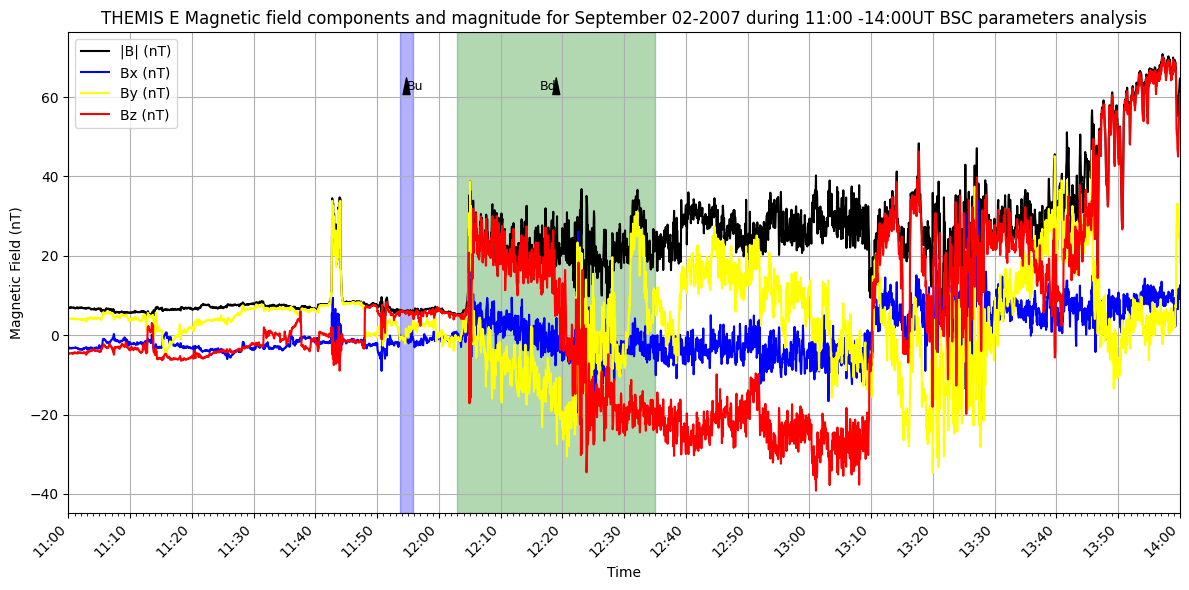

In [ ]:
# Re-load df_fgm for THE data
try:
    df_fgm_the = pd.read_csv('/content/THE_L2_FGM_SEPT11_14.csv') # Update path if necessary
except FileNotFoundError as e:
    print(f"Error loading file for THE: {e}")
    print("Please ensure the CSV file for THE is located in your Google Drive 'My Drive' folder, or update the path.")
    raise # Re-raise the error to stop execution if not handled

# Convert 'UT__yyyy-mm-ddThh:mm:ss.sssZ' to datetime objects
df_fgm_the['Time'] = pd.to_datetime(df_fgm_the['UT__yyyy-mm-ddThh:mm:ss.sssZ'])

# Calculate magnetic field magnitude |B|
df_fgm_the['|B|'] = np.sqrt(
    df_fgm_the['BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)']**2 +
    df_fgm_the['BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)']**2 +
    df_fgm_the['BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)']**2
)

# Define the shock crossing time for THE (PLACEHOLDER - PLEASE UPDATE)
shock_time_the = pd.to_datetime('2007-09-02T11:56:40Z') # Using same placeholder as THB for now

# Define upstream and downstream intervals for THE (PLACEHOLDER - PLEASE UPDATE)
upstream_start_the = pd.to_datetime('2007-09-02T11:53:40Z') # Extended start time
upstream_end_the = pd.to_datetime('2007-09-02T11:55:50Z') # Extended end time

downstream_start_the = pd.to_datetime('2007-09-02T12:03:00Z') # Extended start time
downstream_end_the = pd.to_datetime('2007-09-02T12:35:00Z') # Extended end time

# --- Create single subplot ---
fig_the, ax1_the = plt.subplots(1, 1, figsize=(12, 6))

# --- Plot 1: Magnetic Field Components and Magnitude ---
ax1_the.plot(df_fgm_the['Time'], df_fgm_the['|B|'], label='|B| (nT)', color='black')
ax1_the.plot(df_fgm_the['Time'], df_fgm_the['BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)'], label='Bx (nT)', color='blue')
ax1_the.plot(df_fgm_the['Time'], df_fgm_the['BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)'], label='By (nT)', color='yellow')
ax1_the.plot(df_fgm_the['Time'], df_fgm_the['BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'], label='Bz (nT)', color='red')

# Add shading for upstream and downstream intervals
ax1_the.axvspan(upstream_start_the, upstream_end_the, color='blue', alpha=0.3) # Increased alpha
ax1_the.axvspan(downstream_start_the, downstream_end_the, color='green', alpha=0.3) # Changed color to green

ax1_the.set_title('THEMIS E Magnetic field components and magnitude for September 02-2007 during 11:00 -14:00UT BSC parameters analysis')
ax1_the.set_xlabel('Time')
ax1_the.set_ylabel('Magnetic Field (nT)')
ax1_the.grid(True)

# Set x-axis major ticks to 10-minute intervals and minor ticks to 1-minute intervals
ax1_the.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
ax1_the.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
ax1_the.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')) # Format to show hour and minute
plt.xticks(rotation=45, ha='right') # Rotate and align for better readability

# Set x-axis limits to 11:00 to 14:00
ax1_the.set_xlim(pd.to_datetime('2007-09-02T11:00:00Z'), pd.to_datetime('2007-09-02T14:00:00Z')) # Adjust as needed

# --- MVA and COP Calculations Placeholder (will be filled in next step) ---
mag_field_cols_the = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)',
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]

# This part will be completed in the next step after the plot is displayed.

# --- Add original legend for B components ---
ax1_the.legend(loc='upper left')

# --- Add annotations for shaded regions (adjusted position) ---
ylim_the = ax1_the.get_ylim()
y_text_pos_the = ylim_the[1] * 0.80 # Position for the text, lower than before
y_arrow_tip_pos_the = ylim_the[1] * 0.85 # Position for the arrow tip, slightly higher than text

x_before_bsc_the = upstream_start_the + (upstream_end_the - upstream_start_the) / 2
ax1_the.annotate('Bu', xy=(x_before_bsc_the, y_arrow_tip_pos_the), xytext=(x_before_bsc_the, y_text_pos_the),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             horizontalalignment='left', verticalalignment='bottom', fontsize=9)
x_after_bsc_the = downstream_start_the + (downstream_end_the - downstream_start_the) / 2
ax1_the.annotate('Bd', xy=(x_after_bsc_the, y_arrow_tip_pos_the), xytext=(x_after_bsc_the, y_text_pos_the),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             horizontalalignment='right', verticalalignment='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/content/THE_20070902_FGM_Plot.png') # Unique filename for THE
plt.show()

In [ ]:
# Perform MVA on the FGM data for THEMIS E
# The 'mva' function was defined earlier in the notebook
# Use mag_field_cols_the which was defined in the previous cell
evals_the, evecs_the = mva(df_fgm_the, *mag_field_cols_the)

# Identify the minimum variance direction (shock normal) for THEMIS E
MVA_the = evecs_the[:, 2] # Eigenvector corresponding to the smallest eigenvalue (lambda_3)

# Calculate average B for upstream and downstream regions for THEMIS E
# Using the defined upstream and downstream intervals for THEMIS E
df_upstream_the = df_fgm_the[(df_fgm_the['Time'] >= upstream_start_the) & (df_fgm_the['Time'] <= upstream_end_the)]
df_downstream_the = df_fgm_the[(df_fgm_the['Time'] >= downstream_start_the) & (df_fgm_the['Time'] <= downstream_end_the)]

B_upstream_avg_the = df_upstream_the[mag_field_cols_the].mean().values
B_downstream_avg_the = df_downstream_the[mag_field_cols_the].mean().values

# Calculate nCOP (Coplanarity Normal) for THEMIS E
if len(B_upstream_avg_the) > 0 and len(B_downstream_avg_the) > 0:
    nCOP_unnormalized_the = np.cross(B_upstream_avg_the, B_downstream_avg_the)
    if np.linalg.norm(nCOP_unnormalized_the) != 0:
        nCOP_the = nCOP_unnormalized_the / np.linalg.norm(nCOP_unnormalized_the)
    else:
        nCOP_the = np.array([np.nan, np.nan, np.nan]) # Handle case where cross product is zero
else:
    nCOP_the = np.array([np.nan, np.nan, np.nan])

# Calculate the angle between MVA and nCOP for THEMIS E
dot_product_the = np.dot(MVA_the, nCOP_the)
dot_product_the = np.clip(dot_product_the, -1.0, 1.0) # Clip to avoid floating point errors outside [-1, 1]
angle_rad_the = np.arccos(dot_product_the)
angle_deg_the = np.degrees(angle_rad_the)

# Calculate additional ratios for THEMIS E
ratio_lambda1_lambda2_the = evals_the[0] / evals_the[1] # lambda_1 / lambda_2
reliability_ratio_the = evals_the[1] / evals_the[2] # lambda_2 / lambda_3

print("\nTHEMIS E MVA and COP Analysis Results:")
print(f"  MVA Eigenvalues (lambda_1, lambda_2, lambda_3): {evals_the}")
print(f"  Eigenvector (nMVA) for lambda_3 (shock normal): {MVA_the}")
print(f"  Average Upstream Magnetic Field (Bu_avg): {B_upstream_avg_the}")
print(f"  Average Downstream Magnetic Field (Bd_avg): {B_downstream_avg_the}")
print(f"  Coplanarity Normal (nCOP): {nCOP_the}")
print(f"  Angle between nMVA and nCOP: {angle_deg_the:.2f}°")
print(f"  MVA Eigenvalue Ratio (lambda_1 / lambda_2): {ratio_lambda1_lambda2_the:.2f}")
print(f"  MVA Reliability Ratio (lambda_2 / lambda_3): {reliability_ratio_the:.2f}")

# Add MVA, nCOP, and angle as text directly on the plot to the bottom left
# Using ax1_the from the previous plot
ax1_the.text(0.02, 0.17, fr'$ \lambda_2 / \lambda_3 $ = {reliability_ratio_the:.2f}',
         transform=ax1_the.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='left')
ax1_the.text(0.02, 0.12, f'nMVA = [{MVA_the[0]:.2f}, {MVA_the[1]:.2f}, {MVA_the[2]:.2f}]',
         transform=ax1_the.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='left')
ax1_the.text(0.02, 0.07, f'nCOP = [{nCOP_the[0]:.2f}, {nCOP_the[1]:.2f}, {nCOP_the[2]:.2f}]',
         transform=ax1_the.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='left')
ax1_the.text(0.02, 0.02, f'Angle(nMVA, nCOP) = {angle_deg_the:.2f}°',
         transform=ax1_the.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='left')

# Re-display the plot with the new annotations
fig_the.canvas.draw()
fig_the.show()


THEMIS E MVA and COP Analysis Results:
  MVA Eigenvalues (lambda_1, lambda_2, lambda_3): [537.38493183 123.24686758  14.26246693]
  Eigenvector (nMVA) for lambda_3 (shock normal): [ 0.98081105 -0.07770812 -0.17880473]
  Average Upstream Magnetic Field (Bu_avg): [-0.88620274  0.33211381  5.80658047]
  Average Downstream Magnetic Field (Bd_avg): [-0.73430411 -3.22275019  2.14631239]
  Coplanarity Normal (nCOP): [ 0.98046541 -0.11920082  0.15645686]
  Angle between nMVA and nCOP: 19.45°
  MVA Eigenvalue Ratio (lambda_1 / lambda_2): 4.36
  MVA Reliability Ratio (lambda_2 / lambda_3): 8.64


In [ ]:
# Placeholder values for number densities (nu_the, nd_the) in cm^-3 and velocities (Vu_the, Vd_the) in km/s
# YOU SHOULD REPLACE THESE WITH ACTUAL VALUES FROM YOUR DATA OR ASSUMPTIONS
nu_the = 5.0 # Upstream number density in cm^-3 (Placeholder)
nd_the = 15.0 # Downstream number density in cm^-3 (Placeholder)
Vu_the = np.array([100.0, -50.0, 20.0]) # Upstream velocity vector in km/s (Placeholder)
Vd_the = np.array([50.0, -20.0, 10.0]) # Downstream velocity vector in km/s (Placeholder)

# Use the MVA shock normal calculated for THEMIS E
normal_the = MVA_the

# Calculate mass densities (converted from cm^-3 to m^-3 by multiplying by 1e6)
rho_u_the = nu_the * 1e6 * mp # Upstream mass density in kg/m^3
rho_d_the = nd_the * 1e6 * mp # Downstream mass density in kg/m^3

# Calculate normal components of velocities
Vnu_the = np.dot(Vu_the, normal_the) # Normal component of upstream velocity in km/s
Vnd_the = np.dot(Vd_the, normal_the) # Normal component of downstream velocity in km/s

# Placeholder values for upstream and downstream temperatures (in eV)
# YOU SHOULD REPLACE THESE WITH ACTUAL VALUES FROM YOUR DATA
Tu_eV_the = 10.0  # Upstream temperature in eV
Td_eV_the = 100.0 # Downstream temperature in eV

# Convert temperatures from eV to Kelvin (1 eV = 11604 K)
Tu_the = Tu_eV_the * 11604.0 # Upstream temperature in Kelvin
Td_the = Td_eV_the * 11604.0 # Downstream temperature in Kelvin

# Calculate Shock Speed (Vs_the) using mass conservation equation:
# rho_u_the * (Vs_the - Vnu_the) = rho_d_the * (Vs_the - Vnd_the)
# Vs_the * (rho_d_the - rho_u_the) = rho_d_the * Vnd_the - rho_u_the * Vnu_the
# Vs_the = (rho_d_the * Vnd_the - rho_u_the * Vnu_the) / (rho_d_the - rho_u_the)

# Ensure rho_d_the - rho_u_the is not zero to avoid division by zero
if (rho_d_the - rho_u_the) != 0:
    Vs_the = (rho_d_the * Vnd_the - rho_u_the * Vnu_the) / (rho_d_the - rho_u_the)
else:
    Vs_the = np.nan # Or handle the case as appropriate

# Calculate Density Ratio
density_ratio_the = rho_d_the / rho_u_the

# Calculate Pressure using the ideal gas law: P = n * k_B * T
# Convert number densities from cm^-3 to m^-3 by multiplying by 1e6
Pu_the = (nu_the * 1e6) * k_B * Tu_the # Upstream pressure in Pascals
Pd_the = (nd_the * 1e6) * k_B * Td_the # Downstream pressure in Pascals

print("\nTHEMIS E Calculated Plasma and Shock Parameters:")
print(f"  Upstream number density (nu_the): {nu_the} cm^-3")
print(f"  Downstream number density (nd_the): {nd_the} cm^-3")
print(f"  Upstream velocity vector (Vu_the): {Vu_the} km/s")
print(f"  Downstream velocity vector (Vd_the): {Vd_the} km/s")
print(f"  Shock normal (normal_the): {normal_the}")
print(f"  Upstream mass density (rho_u_the): {rho_u_the:.3e} kg/m^3")
print(f"  Downstream mass density (rho_d_the): {rho_d_the:.3e} kg/m^3")
print(f"  Normal component of upstream velocity (Vnu_the): {Vnu_the:.2f} km/s")
print(f"  Normal component of downstream velocity (Vnd_the): {Vnd_the:.2f} km/s")
print(f"  Upstream Temperature (Tu_the): {Tu_the:.2f} K ({Tu_eV_the:.1f} eV)")
print(f"  Downstream Temperature (Td_the): {Td_the:.2f} K ({Td_eV_the:.1f} eV)")
print(f"  Shock Speed (Vs_the): {Vs_the:.2f} km/s")
print(f"  Density Ratio (rho_d_the / rho_u_the): {density_ratio_the:.2f}")
print(f"  Upstream Pressure (Pu_the): {Pu_the:.3e} Pa")
print(f"  Downstream Pressure (Pd_the): {Pd_the:.3e} Pa")


THEMIS E Calculated Plasma and Shock Parameters:
  Upstream number density (nu_the): 5.0 cm^-3
  Downstream number density (nd_the): 15.0 cm^-3
  Upstream velocity vector (Vu_the): [100. -50.  20.] km/s
  Downstream velocity vector (Vd_the): [ 50. -20.  10.] km/s
  Shock normal (normal_the): [ 0.98081105 -0.07770812 -0.17880473]
  Upstream mass density (rho_u_the): 8.363e-21 kg/m^3
  Downstream mass density (rho_d_the): 2.509e-20 kg/m^3
  Normal component of upstream velocity (Vnu_the): 98.39 km/s
  Normal component of downstream velocity (Vnd_the): 48.81 km/s
  Upstream Temperature (Tu_the): 116040.00 K (10.0 eV)
  Downstream Temperature (Td_the): 1160400.00 K (100.0 eV)
  Shock Speed (Vs_the): 24.01 km/s
  Density Ratio (rho_d_the / rho_u_the): 3.00
  Upstream Pressure (Pu_the): 8.011e-12 Pa
  Downstream Pressure (Pd_the): 2.403e-10 Pa


In [ ]:
Vu_s_the = Vu_the - Vs_the * normal_the
Vd_s_the = Vd_the - Vs_the * normal_the

print("\nTHEMIS E Transformed Velocities in Shock Frame:")
print(f"  Upstream velocity in shock frame (Vu_s_the): {Vu_s_the} km/s")
print(f"  Downstream velocity in shock frame (Vd_s_the): {Vd_s_the} km/s")


THEMIS E Transformed Velocities in Shock Frame:
  Upstream velocity in shock frame (Vu_s_the): [ 76.44602542 -48.13385552  24.29395858] km/s
  Downstream velocity in shock frame (Vd_s_the): [ 26.44602542 -18.13385552  14.29395858] km/s


In [ ]:
Bu_the = B_upstream_avg_the
Bd_the = B_downstream_avg_the

# Calculate normal components of magnetic field for THEMIS E
Bn_u_the = np.dot(Bu_the, normal_the)
Bn_d_the = np.dot(Bd_the, normal_the)

# Calculate tangential components of magnetic field for THEMIS E
Bt_u_the = Bu_the - Bn_u_the * normal_the
Bt_d_the = Bd_the - Bn_d_the * normal_the

# Calculate normal components of velocity in the shock frame for THEMIS E
Vn_u_the = np.dot(Vu_s_the, normal_the)
Vn_d_the = np.dot(Vd_s_the, normal_the)

# Calculate tangential components of velocity in the shock frame for THEMIS E
Vt_u_the = Vu_s_the - Vn_u_the * normal_the
Vt_d_the = Vd_s_the - Vn_d_the * normal_the

print("\nTHEMIS E Magnetic Field Components:")
print(f"  Upstream Normal Magnetic Field (Bn_u_the): {Bn_u_the:.2f} nT")
print(f"  Downstream Normal Magnetic Field (Bn_d_the): {Bn_d_the:.2f} nT")
print(f"  Upstream Tangential Magnetic Field (Bt_u_the): {Bt_u_the} nT")
print(f"  Downstream Tangential Magnetic Field (Bt_d_the): {Bt_d_the} nT")

print("\nTHEMIS E Velocity Components in Shock Frame:")
print(f"  Upstream Normal Velocity (Vn_u_the): {Vn_u_the:.2f} km/s")
print(f"  Downstream Normal Velocity (Vn_d_the): {Vn_d_the:.2f} km/s")
print(f"  Upstream Tangential Velocity (Vt_u_the): {Vt_u_the} km/s")
print(f"  Downstream Tangential Velocity (Vt_d_the): {Vt_d_the} km/s")


THEMIS E Magnetic Field Components:
  Upstream Normal Magnetic Field (Bn_u_the): -1.93 nT
  Downstream Normal Magnetic Field (Bn_d_the): -0.85 nT
  Upstream Tangential Magnetic Field (Bt_u_the): [1.00994966 0.18188463 5.46090633] nT
  Downstream Tangential Magnetic Field (Bt_d_the): [ 0.10286768 -3.289078    1.99369352] nT

THEMIS E Velocity Components in Shock Frame:
  Upstream Normal Velocity (Vn_u_the): 74.38 km/s
  Downstream Normal Velocity (Vn_d_the): 24.79 km/s
  Upstream Tangential Velocity (Vt_u_the): [  3.49759216 -42.35426553  37.59267173] km/s
  Downstream Tangential Velocity (Vt_d_the): [  2.129881   -16.20732553  18.72686297] km/s


In [ ]:
# Calculate mass flux in the upstream and downstream regions for THEMIS E
# Note: Vn_u_the and Vn_d_the are in km/s, so we convert them to m/s by multiplying by 1000
mass_u_the = rho_u_the * (Vn_u_the * 1000) # Upstream mass flux in kg/(m^2 * s)
mass_d_the = rho_d_the * (Vn_d_the * 1000) # Downstream mass flux in kg/(m^2 * s)

print("\nTHEMIS E - Testing RH Equation 1 (Mass Conservation):")
print(f"  Upstream Mass Flux (mass_u_the): {mass_u_the:.3e} kg/(m^2 * s)")
print(f"  Downstream Mass Flux (mass_d_the): {mass_d_the:.3e} kg/(m^2 * s)")
print(f"  Difference (mass_u_the - mass_d_the): {mass_u_the - mass_d_the:.3e} kg/(m^2 * s)")


THEMIS E - Testing RH Equation 1 (Mass Conservation):
  Upstream Mass Flux (mass_u_the): 6.220e-16 kg/(m^2 * s)
  Downstream Mass Flux (mass_d_the): 6.220e-16 kg/(m^2 * s)
  Difference (mass_u_the - mass_d_the): 1.972e-31 kg/(m^2 * s)


In [ ]:
print("\nTHEMIS E - Testing RH Equation 2 (Normal Magnetic Field Conservation):")
print(f"  Upstream Normal Magnetic Field (Bn_u_the): {Bn_u_the:.2f} nT")
print(f"  Downstream Normal Magnetic Field (Bn_d_the): {Bn_d_the:.2f} nT")
print(f"  Difference (Bn_u_the - Bn_d_the): {Bn_u_the - Bn_d_the:.2e} nT")


THEMIS E - Testing RH Equation 2 (Normal Magnetic Field Conservation):
  Upstream Normal Magnetic Field (Bn_u_the): -1.93 nT
  Downstream Normal Magnetic Field (Bn_d_the): -0.85 nT
  Difference (Bn_u_the - Bn_d_the): -1.08e+00 nT


In [ ]:
# Calculate upstream electric field Eu_the
Eu_the = Vn_u_the * Bt_u_the - Bn_u_the * Vt_u_the

# Calculate downstream electric field Ed_the
Ed_the = Vn_d_the * Bt_d_the - Bn_d_the * Vt_d_the

print("\nTHEMIS E - Testing RH Equation 3 (Electric Field Conservation):")
print(f"  Upstream Electric Field (Eu_the): {Eu_the} (km/s * nT)")
print(f"  Downstream Electric Field (Ed_the): {Ed_the} (km/s * nT)")
print(f"  Difference (Eu_the - Ed_the): {Eu_the - Ed_the} (km/s * nT)")


THEMIS E - Testing RH Equation 3 (Electric Field Conservation):
  Upstream Electric Field (Eu_the): [ 81.8773535  -68.35357678 478.83432313] (km/s * nT)
  Downstream Electric Field (Ed_the): [  4.3682436  -95.37617996  65.4117231 ] (km/s * nT)
  Difference (Eu_the - Ed_the): [ 77.50910991  27.02260318 413.42260003] (km/s * nT)


In [ ]:
mu0 = 4 * np.pi * 1e-7 # Permeability of free space in H/m (or N/A^2)

# Calculate upstream momentum (Mom_u_the) in Pa
# Note: Vn_u_the is in km/s, so we convert it to m/s by multiplying by 1000
# Bt_u_the is in nT, so we convert it to T by multiplying by 1e-9
Mom_u_the = rho_u_the * (Vn_u_the * 1000)**2 + Pu_the + np.dot(Bt_u_the * 1e-9, Bt_u_the * 1e-9) / (2 * mu0)

# Calculate downstream momentum (Mom_d_the) in Pa
# Note: Vn_d_the is in km/s, so we convert it to m/s by multiplying by 1000
# Bt_d_the is in nT, so we convert it to T by multiplying by 1e-9
Mom_d_the = rho_d_the * (Vn_d_the * 1000)**2 + Pd_the + np.dot(Bt_d_the * 1e-9, Bt_d_the * 1e-9) / (2 * mu0)

print("\nTHEMIS E - Testing RH Equation 4 (Momentum Conservation):")
print(f"  Upstream Momentum (Mom_u_the): {Mom_u_the:.3e} Pa")
print(f"  Downstream Momentum (Mom_d_the): {Mom_d_the:.3e} Pa")
print(f"  Difference (Mom_u_the - Mom_d_the): {Mom_u_the - Mom_d_the:.3e} Pa")


THEMIS E - Testing RH Equation 4 (Momentum Conservation):
  Upstream Momentum (Mom_u_the): 6.656e-11 Pa
  Downstream Momentum (Mom_d_the): 2.616e-10 Pa
  Difference (Mom_u_the - Mom_d_the): -1.951e-10 Pa


In [ ]:
# Calculate upstream tangential momentum (Tang_u_the)
# rho_u_the in kg/m^3, Vn_u_the in km/s (convert to m/s), Vt_u_the in km/s (convert to m/s vector)
# Bn_u_the in nT (convert to T), Bt_u_the in nT (convert to T vector)
Tang_u_the = rho_u_the * (Vn_u_the * 1000) * (Vt_u_the * 1000) - ((Bn_u_the * 1e-9) * (Bt_u_the * 1e-9)) / mu0

# Calculate downstream tangential momentum (Tang_d_the)
# rho_d_the in kg/m^3, Vn_d_the in km/s (convert to m/s), Vt_d_the in km/s (convert to m/s vector)
# Bn_d_the in nT (convert to T), Bt_d_the in nT (convert to T vector)
Tang_d_the = rho_d_the * (Vn_d_the * 1000) * (Vt_d_the * 1000) - ((Bn_d_the * 1e-9) * (Bt_d_the * 1e-9)) / mu0

print("\nTHEMIS E - Testing RH Equation 5 (Tangential Momentum Conservation):")
print(f"  Upstream Tangential Momentum (Tang_u_the): {Tang_u_the} Pa")
print(f"  Downstream Tangential Momentum (Tang_d_the): {Tang_d_the} Pa")
print(f"  Difference (Tang_u_the - Tang_d_the): {Tang_u_the - Tang_d_the} Pa")


THEMIS E - Testing RH Equation 5 (Tangential Momentum Conservation):
  Upstream Tangential Momentum (Tang_u_the): [ 3.72925188e-12 -2.60646776e-11  3.17839950e-11] Pa
  Downstream Tangential Momentum (Tang_d_the): [ 1.39466431e-12 -1.23150639e-11  1.30023555e-11] Pa
  Difference (Tang_u_the - Tang_d_the): [ 2.33458757e-12 -1.37496136e-11  1.87816394e-11] Pa


In [ ]:
# Calculate upstream energy flux (Eu_rh6_the) in W/m^2 for THEMIS E
# Vn_u_the and Vu_s_the are in km/s, convert to m/s by multiplying by 1000
Eu_rh6_the = (0.5 * rho_u_the * np.linalg.norm(Vu_s_the * 1000)**2 + \
              gamma / (gamma - 1) * Pu_the) * (Vn_u_the * 1000)

# Calculate downstream energy flux (Ed_rh6_the) in W/m^2 for THEMIS E
# Vn_d_the and Vd_s_the are in km/s, convert to m/s by multiplying by 1000
Ed_rh6_the = (0.5 * rho_d_the * np.linalg.norm(Vd_s_the * 1000)**2 + \
              gamma / (gamma - 1) * Pd_the) * (Vn_d_the * 1000)

print("\nTHEMIS E - Testing RH Equation 6 (Energy Flux Conservation):")
print(f"  Upstream Energy Flux (Eu_rh6_the): {Eu_rh6_the:.3e} W/m^2")
print(f"  Downstream Energy Flux (Ed_rh6_the): {Ed_rh6_the:.3e} W/m^2")
print(f"  Difference (Eu_rh6_the - Ed_rh6_the): {Eu_rh6_the - Ed_rh6_the:.3e} W/m^2")


THEMIS E - Testing RH Equation 6 (Energy Flux Conservation):
  Upstream Energy Flux (Eu_rh6_the): 4.211e-06 W/m^2
  Downstream Energy Flux (Ed_rh6_the): 1.528e-05 W/m^2
  Difference (Eu_rh6_the - Ed_rh6_the): -1.107e-05 W/m^2


In [ ]:
# Calculate relative errors for all RH equations for THEMIS E

# RH Eq 1 (Mass Conservation)
error_rh1_the = error(mass_u_the, mass_d_the)

# RH Eq 2 (Normal Magnetic Field Conservation)
error_rh2_the = error(Bn_u_the, Bn_d_the)

# RH Eq 3 (Electric Field Conservation - using magnitudes)
Eu_mag_the = np.linalg.norm(Eu_the)
Ed_mag_the = np.linalg.norm(Ed_the)
error_rh3_the = error(Eu_mag_the, Ed_mag_the)

# RH Eq 4 (Momentum Conservation)
error_rh4_the = error(Mom_u_the, Mom_d_the)

# RH Eq 5 (Tangential Momentum Conservation - using magnitudes)
Tang_u_mag_the = np.linalg.norm(Tang_u_the)
Tang_d_mag_the = np.linalg.norm(Tang_d_the)
error_rh5_the = error(Tang_u_mag_the, Tang_d_mag_the)

# RH Eq 6 (Energy Flux Conservation)
error_rh6_the = error(Eu_rh6_the, Ed_rh6_the)

# Prepare data for the table for THEMIS E
rh_summary_data_the = {
    'RH Equation': [
        '1 (Mass Conservation)',
        '2 (Normal B Conservation)',
        '3 (Electric Field Conservation)',
        '4 (Momentum Conservation)',
        '5 (Tangential Momentum Conservation)',
        '6 (Energy Flux Conservation)'
    ],
    'Upstream Value': [
        f'{mass_u_the:.3e} kg/(m^2 * s)',
        f'{Bn_u_the:.2f} nT',
        f'{Eu_mag_the:.2f} (km/s * nT)',
        f'{Mom_u_the:.3e} Pa',
        f'{Tang_u_mag_the:.3e} Pa',
        f'{Eu_rh6_the:.3e} W/m^2'
    ],
    'Downstream Value': [
        f'{mass_d_the:.3e} kg/(m^2 * s)',
        f'{Bn_d_the:.2f} nT',
        f'{Ed_mag_the:.2f} (km/s * nT)',
        f'{Mom_d_the:.3e} Pa',
        f'{Tang_d_mag_the:.3e} Pa',
        f'{Ed_rh6_the:.3e} W/m^2'
    ],
    'Difference': [
        f'{(mass_u_the - mass_d_the):.3e}',
        f'{(Bn_u_the - Bn_d_the):.2e}',
        f'{np.linalg.norm(Eu_the - Ed_the):.2f}', # Magnitude of vector difference
        f'{(Mom_u_the - Mom_d_the):.3e}',
        f'{np.linalg.norm(Tang_u_the - Tang_d_the):.3e}', # Magnitude of vector difference
        f'{(Eu_rh6_the - Ed_rh6_the):.3e}'
    ],
    'Units': [
        'kg/(m^2 * s)',
        'nT',
        '(km/s * nT)',
        'Pa',
        'Pa',
        'W/m^2'
    ],
    'Relative Error (%)': [
        f'{error_rh1_the:.2f}%',
        f'{error_rh2_the:.2f}%',
        f'{error_rh3_the:.2f}%',
        f'{error_rh4_the:.2f}%',
        f'{error_rh5_the:.2f}%',
        f'{error_rh6_the:.2f}%'
    ]
}

rh_summary_df_the = pd.DataFrame(rh_summary_data_the)
print("\nRankine-Hugoniot Summary for THEMIS E:")
display(rh_summary_df_the)

print("\nNote: A relative error of 0.00% often indicates values are identical or extremely close, given floating point precision. Higher errors suggest non-conservation based on the current placeholder values. Remember to replace placeholder values with actual data for accurate physical results.")


Rankine-Hugoniot Summary for THEMIS E:


,RH Equation,Upstream Value,Downstream Value,Difference,Units,Relative Error (%)
0,1 (Mass Conservation),6.220e-16 kg/(m^2 * s),6.220e-16 kg/(m^2 * s),1.972e-31,kg/(m^2 * s),0.00%
1,2 (Normal B Conservation),-1.93 nT,-0.85 nT,-1.08e+00,nT,55.85%
2,3 (Electric Field Conservation),490.57 (km/s * nT),115.73 (km/s * nT),421.49,(km/s * nT),76.41%
3,4 (Momentum Conservation),6.656e-11 Pa,2.616e-10 Pa,-1.951e-10,Pa,74.56%
4,5 (Tangential Momentum Conservation),4.127e-11 Pa,1.796e-11 Pa,2.339e-11,Pa,56.48%
5,6 (Energy Flux Conservation),4.211e-06 W/m^2,1.528e-05 W/m^2,-1.107e-05,W/m^2,72.44%



Note: A relative error of 0.00% often indicates values are identical or extremely close, given floating point precision. Higher errors suggest non-conservation based on the current placeholder values. Remember to replace placeholder values with actual data for accurate physical results.


In [ ]:
print(df_fgm_the.columns)

Index(['UT__yyyy-mm-ddThh:mm:ss.sssZ', 'FGS-D_B_TOTAL__nT_(All_Qs)',
       'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)', 'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
       'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)', 'BX_FGS-D_(@_1_)_nT_GSM_(All_Qs)',
       'BY_FGS-D_(@_2_)_nT_GSM_(All_Qs)', 'BZ_FGS-D_(@_3_)_nT_GSM_(All_Qs)',
       'Time'],
      dtype='object')
